# Decodability along the trial (single-session PSTH)
Decodes **stimulus side, block, choice, feedback** from the population at each time bin (aligned to
stimulus onset), for one session at a time, with a matched **control** line overlaid:
- **block** → IBL pseudosession null (generative, biased-only, preserves block autocorrelation → controls slow drift)
- **stimulus / choice / feedback** → label-shuffle null

Knobs: cap trial count (`N_TRIALS`), balance classes (`BALANCE_CLASSES`), trailing smoothing window, #PCs.
`REGION_MODE` = `'pooled'` (all probes together) or `'per_region'` (one figure per Cosmos region); `MAX_NEURONS` caps neurons per unit.
**To run more sessions:** put eids in `SESSION_EIDS`, or leave it empty and set `AUTO_N` to auto-pick that many good sessions.

*Note: the pseudosession/shuffle null scales with neuron count — pooling all probes (~hundreds of neurons) makes slow drift very decodable, inflating the block control. Per-region + `MAX_NEURONS` gives a lower, more comparable null.*

In [1]:
import numpy as np, pandas as pd, pickle, os, warnings
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from iblatlas.regions import BrainRegions
warnings.filterwarnings('ignore')
plt.rcParams['figure.facecolor'] = 'white'

In [2]:
prefix = '/home/ines/repositories/representation_learning_variability/paper-individuality/'
firing_rates_dir = prefix + 'data/firing_rates/'
trials_path = prefix + '4_mice/all_trials_04-05-2026'
DROP = ['root', 'void']

# ---- which sessions to run ----
SESSION_EIDS = []          # explicit eids to run (e.g. ['b69b86be-af7d-4ecf-8cbf-0cd356afa1bd']); [] -> auto-pick
AUTO_N = 1                 # if SESSION_EIDS empty, auto-pick this many qualifying sessions

# ---- population: pooled vs per-region, and neuron cap ----
REGION_MODE = 'per_region' # 'pooled' (all probes together) or 'per_region' (one figure per Cosmos region)
MAX_NEURONS = 50           # cap #neurons used per unit (random subsample); None = use all
MIN_REGION_NEURONS = 20    # in per_region mode, skip regions with fewer neurons than this

# ---- decoding params ----
N_COMP = 20                # PCA components
CV_FOLDS = 5
N_CONTROL = 20             # #shuffles / #pseudosessions for the control line
SMOOTH_BINS = 3            # trailing (causal) window (~50 ms) for the decode feature
N_TRIALS = None            # cap #trials per variable (None = use all)
BALANCE_CLASSES = True     # downsample to equal class sizes per variable
MIN_NEURONS = 40           # qualifying threshold for auto-picking a session
SAVE_PNG = True            # save a per-unit png alongside the inline plot
SEED = 0
BLK_MEAN = 60; BLK_MIN = 20; BLK_MAX = 100
rng = np.random.default_rng(SEED)

trials_df = pd.read_parquet(trials_path)
br = BrainRegions()
print("params set")

params set


## Helpers

In [3]:
def gen_pseudo_biased(n, rng):
    # IBL biased-block generative sequence (no 0.5 opening): alternating 0.2/0.8,
    # run lengths ~exp(mean 60) truncated [20,100].
    out = []; side = float(rng.choice([0.2, 0.8]))
    while len(out) < n:
        x = rng.exponential(BLK_MEAN)
        while x < BLK_MIN or x > BLK_MAX: x = rng.exponential(BLK_MEAN)
        out += [side] * int(x); side = 0.8 if side == 0.2 else 0.2
    return np.array(out[:n])

def make_folds(X, y):
    skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED); folds = []
    for tr, te in skf.split(X, y):
        sc = StandardScaler().fit(X[tr]); Xtr, Xte = sc.transform(X[tr]), sc.transform(X[te])
        nc = min(N_COMP, Xtr.shape[1], Xtr.shape[0] - 1)
        pca = PCA(n_components=nc, random_state=SEED).fit(Xtr)
        folds.append((tr, te, pca.transform(Xtr), pca.transform(Xte)))
    return folds

def acc_labels(folds, y):
    a = []
    for tr, te, Ztr, Zte in folds:
        if len(np.unique(y[tr])) < 2 or len(np.unique(y[te])) < 2: a.append(np.nan); continue
        a.append(balanced_accuracy_score(y[te], LDA().fit(Ztr, y[tr]).predict(Zte)))
    return np.nanmean(a)

def balance(idx, y, rng):
    classes, counts = np.unique(y, return_counts=True); m = counts.min()
    keep = np.concatenate([rng.choice(idx[y == c], m, replace=False) for c in classes])
    return np.sort(keep)

## Session index + loader (pools all probes of a session)
Firing-rate files are one-per-probe (named by PID); `d['session']` holds the eid. We use a cached
index (`firing_session_pid_index.parquet`) to map session -> probe files, and pool all their neurons.

In [4]:
INDEX_PATH = prefix + 'neural/decoding/firing_session_pid_index.parquet'
idx = pd.read_parquet(INDEX_PATH)                        # columns: filename, session, pid, n_neurons
neurons_per_session = idx.groupby('session')['n_neurons'].sum()

def qualifies(eid):
    tl = trials_df[trials_df.session == eid]
    return (neurons_per_session.get(eid, 0) >= MIN_NEURONS and
            tl.block.isin([0.2, 0.8]).sum() >= 150 and (tl.contrast > 0).sum() >= 150)

def load_session(eid):
    pivs = []; tcols = None; area_map = {}
    for fn in idx.loc[idx.session == eid, 'filename']:
        d = pickle.load(open(firing_rates_dir + fn, 'rb'))
        d = d[~d['area'].isin(DROP)].copy()
        if len(d) == 0: continue
        d['nuid'] = d['pid'].astype(str) + '__' + d['neuron_id'].astype(str)
        area_map.update(dict(zip(d['nuid'], d['area'])))
        tcols = sorted([c for c in d.columns if c.startswith('t_')], key=lambda x: float(x.split('_')[1]))
        pivs.append(d.pivot_table(index='trial_id', columns='nuid', values=tcols))
    tsec = np.array([float(c.split('_')[1]) for c in tcols])
    piv = pd.concat(pivs, axis=1)                        # align on trial_id, pool neurons across probes
    nuids = list(piv[tcols[0]].columns)                  # neuron order along axis 1
    arr = np.stack([piv[tc].values for tc in tcols], axis=-1)   # [trial, neuron, bin] (may contain NaN)
    trial_ids = piv.index.values.astype(int)
    # Cosmos region per neuron (aligned to arr's neuron axis)
    ac = pd.Series({n: area_map[n] for n in nuids}); uac = ac.dropna().unique()
    cmap = dict(zip(uac, br.acronym2acronym(uac, mapping='Cosmos')))
    regions = ac.map(cmap).values
    cs = np.nancumsum(arr, axis=2); sm = arr.copy(); w = SMOOTH_BINS   # trailing-window smoothing
    sm[:, :, w - 1:] = (cs[:, :, w - 1:] - np.concatenate([np.zeros_like(cs[:, :, :1]), cs[:, :, :-w]], axis=2)) / w
    for i in range(w - 1): sm[:, :, i] = cs[:, :, i] / (i + 1)
    sm[np.isnan(arr)] = np.nan                            # keep original NaNs (dropped per-unit later)
    return sm, trial_ids, tsec, regions

# resolve the session list
if SESSION_EIDS:
    eids = list(SESSION_EIDS)
else:
    cand = [s for s in neurons_per_session.sort_values(ascending=False).index if qualifies(s)]
    eids = cand[:AUTO_N]
print(f"{len(eids)} session(s) to run:", [(e[:8], int(neurons_per_session[e])) for e in eids])

1 session(s) to run: [('d33baf74', 515)]


## Decode across time + plot (one figure per session)

session d33baf74 | 515 neurons | mode=per_region | units: [('OLF', 70), ('Isocortex', 223), ('HPF', 21), ('TH', 191)]


  [OLF] 50 neurons, 188 trials | stimulus=0.63 block=0.66 choice=0.62 feedback=0.64


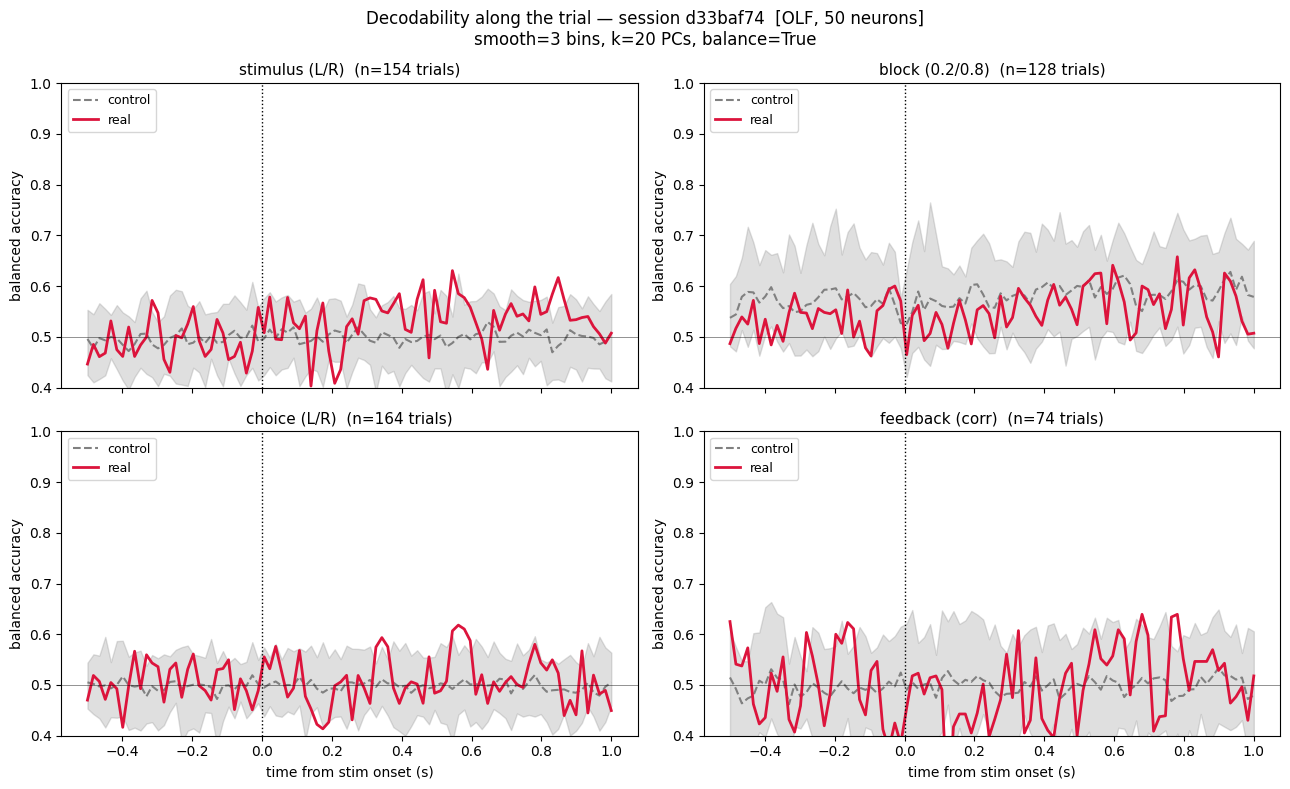

  [Isocortex] 50 neurons, 188 trials | stimulus=0.80 block=0.75 choice=0.77 feedback=0.80


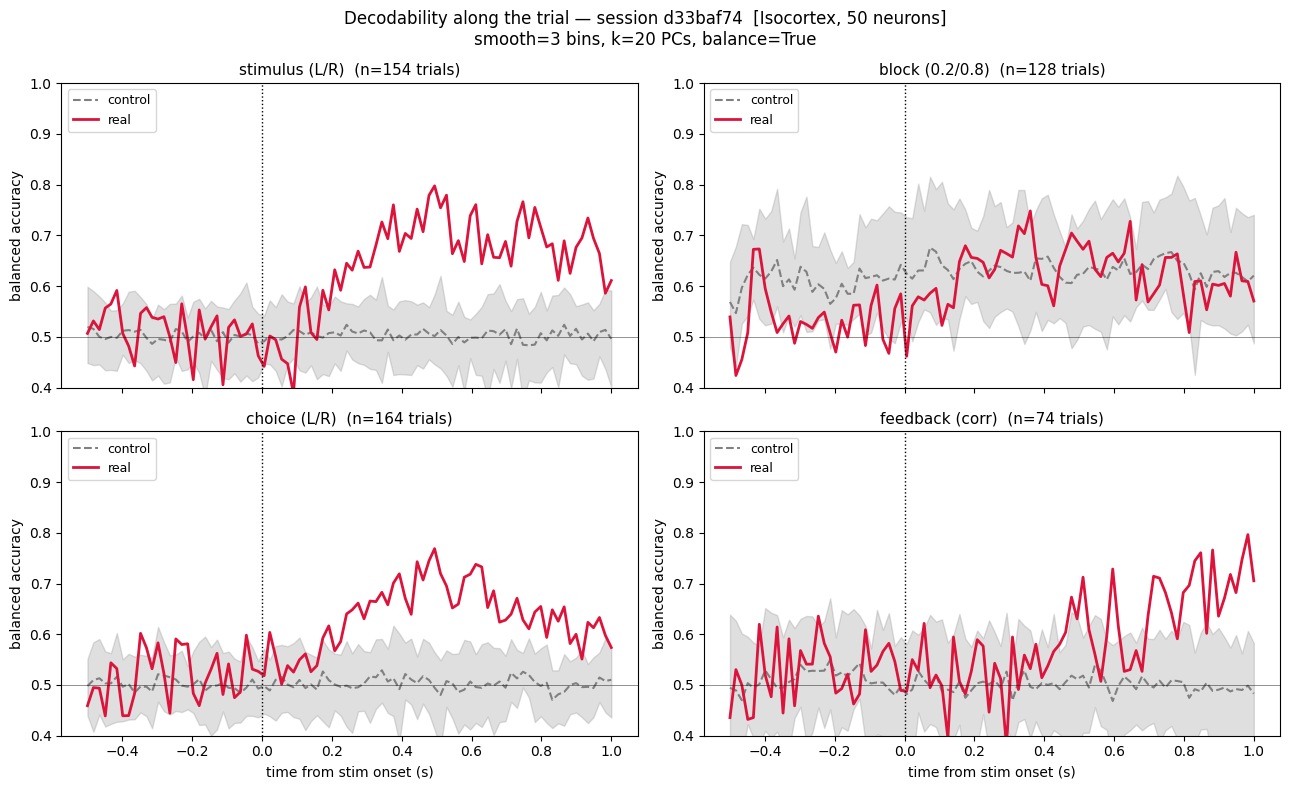

  [HPF] 21 neurons, 188 trials | stimulus=0.68 block=0.68 choice=0.63 feedback=0.70


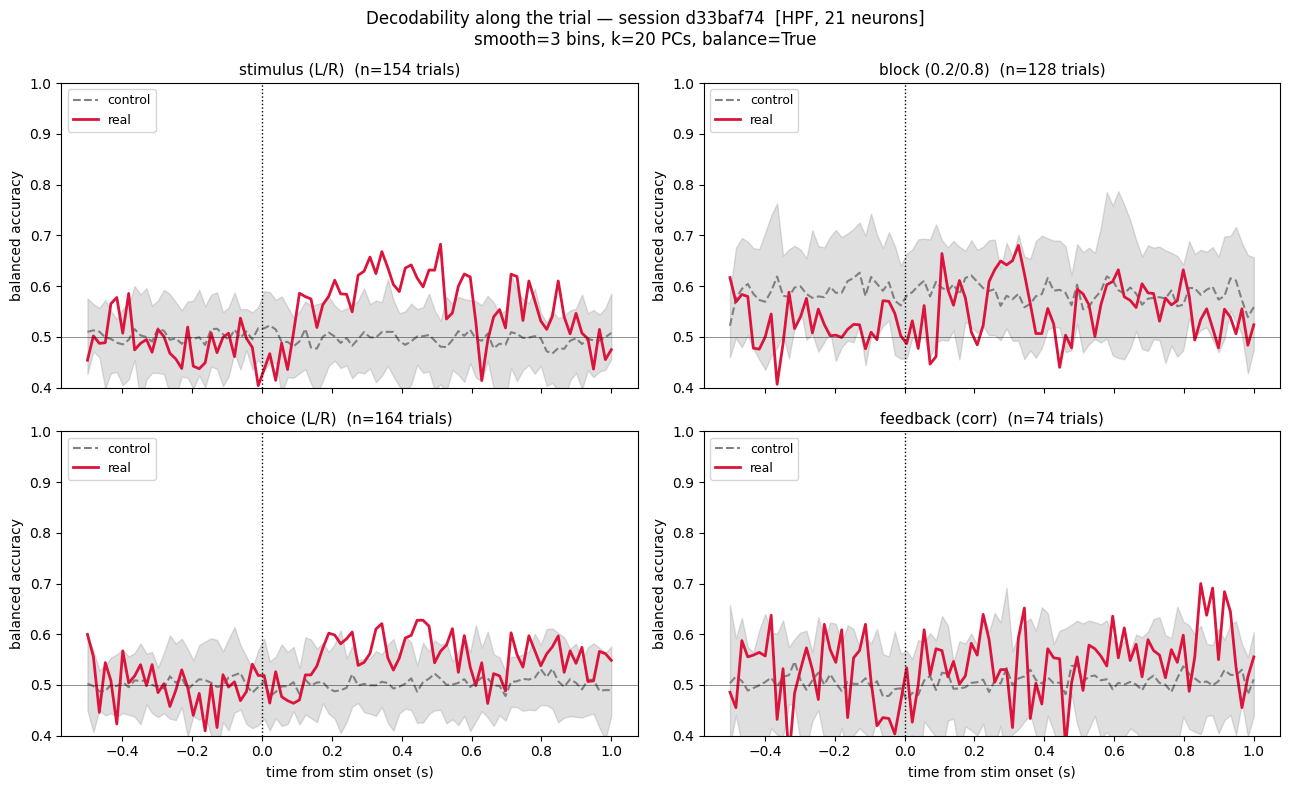

  [TH] 50 neurons, 188 trials | stimulus=0.67 block=0.68 choice=0.70 feedback=0.77


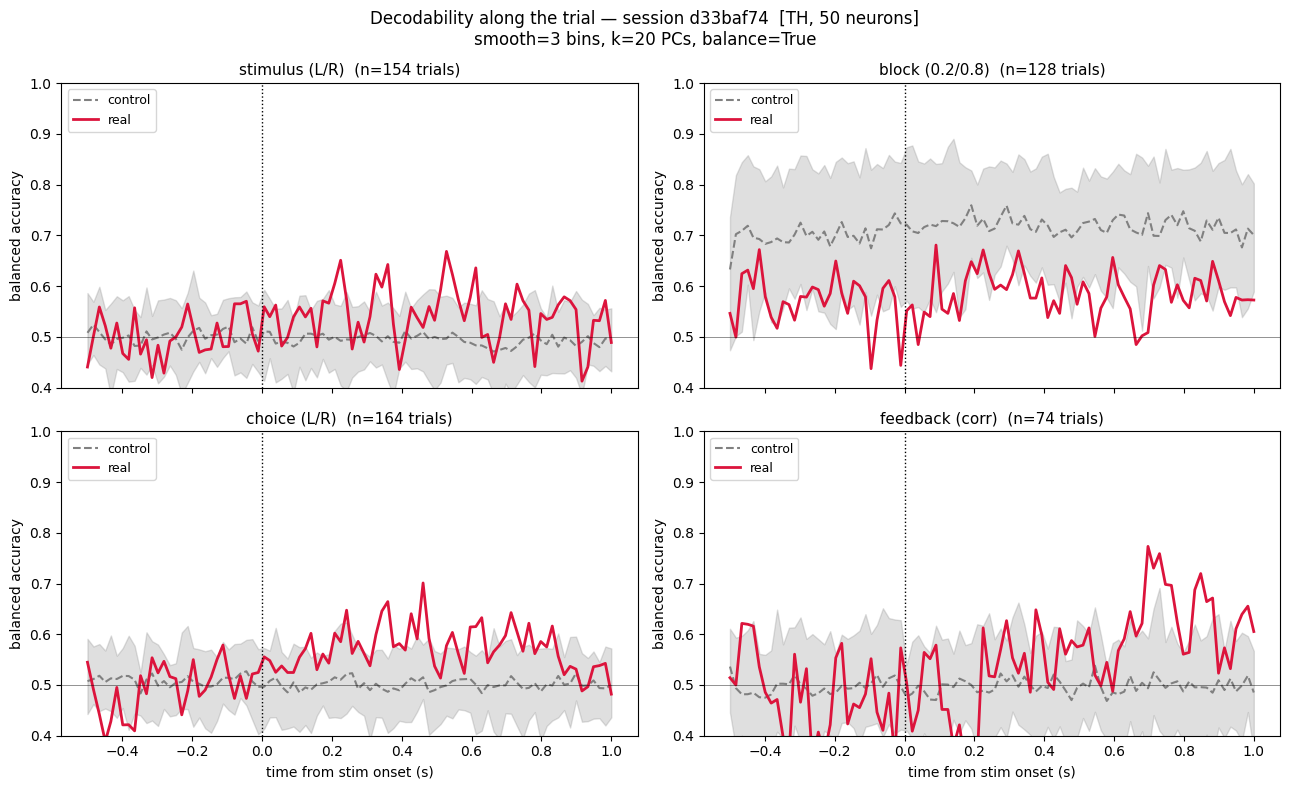

In [5]:
def decode_session(arr, trial_ids, session):
    lab = trials_df[trials_df.session == session].set_index('trial_id').reindex(trial_ids)
    choice_code = (lab['choice'].values == 'right').astype(float)          # left=0 right=1
    correct = lab['correct'].values
    stim_side = np.where(correct == 1, choice_code, 1 - choice_code)       # stim on chosen side if correct
    contrast = lab['contrast'].values; block = lab['block'].values
    VARS = {
        'stimulus (L/R)':  dict(mask=(contrast > 0),              y=stim_side,               ctrl='shuffle'),
        'block (0.2/0.8)': dict(mask=np.isin(block, [0.2, 0.8]),  y=(block == 0.8).astype(float), ctrl='pseudo'),
        'choice (L/R)':    dict(mask=~np.isnan(choice_code),      y=choice_code,             ctrl='shuffle'),
        'feedback (corr)': dict(mask=~np.isnan(correct),          y=correct,                 ctrl='shuffle'),
    }
    results = {}
    for name, cfg in VARS.items():
        m = cfg['mask'] & ~np.isnan(cfg['y']); idx = np.where(m)[0]; y = cfg['y'][idx].astype(int)
        order = np.arange(len(idx))                                        # chronological position (block pseudo)
        if BALANCE_CLASSES:
            kb = balance(np.arange(len(idx)), y, rng); idx, y, order = idx[kb], y[kb], order[kb]
        if N_TRIALS and len(idx) > N_TRIALS:
            s = np.sort(rng.choice(len(idx), N_TRIALS, replace=False)); idx, y, order = idx[s], y[s], order[s]
        span = int(cfg['mask'].sum())
        if cfg['ctrl'] == 'pseudo':
            ctrls = [(gen_pseudo_biased(span, rng)[order] == 0.8).astype(int) for _ in range(N_CONTROL)]
        else:
            ctrls = [rng.permutation(y) for _ in range(N_CONTROL)]
        real_t, ctrl_t = [], []
        for b in range(arr.shape[2]):
            X = arr[idx, :, b]
            if len(np.unique(y)) < 2 or min(np.bincount(y)) < CV_FOLDS:
                real_t.append(np.nan); ctrl_t.append([np.nan] * N_CONTROL); continue
            folds = make_folds(X, y)
            real_t.append(acc_labels(folds, y)); ctrl_t.append([acc_labels(folds, c) for c in ctrls])
        results[name] = dict(real=np.array(real_t), ctrl=np.array(ctrl_t), n=len(idx))
    return results

def plot_session(results, tsec, session, n_neurons, unit_label):
    fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
    for ax, (name, r) in zip(axes.ravel(), results.items()):
        cm = np.nanmean(r['ctrl'], axis=1)
        clo, chi = np.nanpercentile(r['ctrl'], 5, axis=1), np.nanpercentile(r['ctrl'], 95, axis=1)
        ax.fill_between(tsec, clo, chi, color='gray', alpha=0.25)
        ax.plot(tsec, cm, color='gray', lw=1.5, ls='--', label='control')
        ax.plot(tsec, r['real'], color='crimson', lw=2, label='real')
        ax.axvline(0, color='k', ls=':', lw=1); ax.axhline(0.5, color='k', lw=0.6, alpha=0.5)
        ax.set_title(f"{name}  (n={r['n']} trials)", fontsize=11)
        ax.set_ylabel('balanced accuracy'); ax.legend(fontsize=9, loc='upper left'); ax.set_ylim(0.4, 1.0)
    for ax in axes[1]: ax.set_xlabel('time from stim onset (s)')
    fig.suptitle(f"Decodability along the trial — session {session[:8]}  [{unit_label}, {n_neurons} neurons]\n"
                 f"smooth={SMOOTH_BINS} bins, k={N_COMP} PCs, balance={BALANCE_CLASSES}", fontsize=12)
    plt.tight_layout()
    if SAVE_PNG:
        safe = unit_label.replace('/', '-').replace(' ', '')
        plt.savefig(prefix + f'neural/decoding/decoding_psth_{session[:8]}_{safe}.png', dpi=110, bbox_inches='tight')
    plt.show()

def region_units(regions):
    if REGION_MODE == 'per_region':
        units = []
        for r in pd.unique(regions):
            if not isinstance(r, str): continue
            nidx = np.where(regions == r)[0]
            if len(nidx) >= MIN_REGION_NEURONS: units.append((r, nidx))
        return units
    return [('all-pooled', np.arange(len(regions)))]

for eid in eids:
    arr_full, trial_ids, tsec, regions = load_session(eid)
    units = region_units(regions)
    print(f"session {eid[:8]} | {arr_full.shape[1]} neurons | mode={REGION_MODE} | "
          f"units: {[(u, len(n)) for u, n in units]}")
    for label, nidx in units:
        if MAX_NEURONS and len(nidx) > MAX_NEURONS:
            nidx = np.sort(rng.choice(nidx, MAX_NEURONS, replace=False))
        X = arr_full[:, nidx, :]
        tok = ~np.isnan(X).any(axis=(1, 2))                 # trials complete for THIS unit's neurons
        Xr, tids = X[tok], trial_ids[tok]
        if Xr.shape[0] < 60:
            print(f"  [{label}] only {Xr.shape[0]} complete trials, skipping"); continue
        res = decode_session(Xr, tids, eid)
        print(f"  [{label}] {Xr.shape[1]} neurons, {Xr.shape[0]} trials | " +
              " ".join(f"{k.split()[0]}={np.nanmax(v['real']):.2f}" for k, v in res.items()))
        plot_session(res, tsec, eid, Xr.shape[1], label)